#  Social Media and Network Analysis – Assignment 2

In [1]:
print("Jupyter is working")

Jupyter is working


In [2]:
import os

os.listdir("/Volumes/T7DA/SMA class data Ass 2")

['reddit_gaming_madoc.parquet']

In [3]:
import pyarrow.parquet as pq

file_path = "/Volumes/T7DA/SMA class data Ass 2/reddit_gaming_madoc.parquet"

parquet_file = pq.ParquetFile(file_path)

parquet_file.schema

required group field_id=-1 schema {
  optional binary field_id=-1 post_id (String);
  optional int64 field_id=-1 publish_date;
  optional binary field_id=-1 user_id (String);
  optional binary field_id=-1 parent_id (String);
  optional binary field_id=-1 parent_user_id (String);
  optional binary field_id=-1 content (String);
  optional binary field_id=-1 url (String);
  optional binary field_id=-1 language (String);
  optional binary field_id=-1 interaction_type (String);
  optional binary field_id=-1 platform (String);
  optional binary field_id=-1 community (String);
  optional int32 field_id=-1 strict_filter (Null);
  optional double field_id=-1 sentiment_vader;
  optional double field_id=-1 sentiment_textblob;
  optional double field_id=-1 subjectivity_textblob;
  optional double field_id=-1 toxicity_toxigen;
}

In [4]:
import pyarrow.parquet as pq

file_path = "/Volumes/T7DA/SMA class data Ass 2/reddit_gaming_madoc.parquet"

pf = pq.ParquetFile(file_path)

rows = []

# we only read FIRST few row groups (fast chunk access)
for i in range(min(5, pf.num_row_groups)):
    batch = pf.read_row_group(
        i,
        columns=["content", "user_id", "parent_id", "community"]
    )
    rows.append(batch.to_pandas())

import pandas as pd
df = pd.concat(rows, ignore_index=True)

# final safe sample
df = df.sample(5000, random_state=42)

df.head()

,content,user_id,parent_id,community
3556081,"Seriously, I can't believe they bought the One...",1d50cfd0-7f91-59f8-9ae1-221fb0431147,39853bac-793e-5fd1-a1b2-86a1e173edfb,gaming
152612,FERRIS BUELLER OR GTFO!,3cd98235-8b83-5d69-bf6c-b4fb53a2732d,None,gaming
3506026,&gt; Literary\n\n\n,2e0a99f9-cd9b-5bd2-b86e-0d63374f1e29,None,gaming
398302,How are they a Shady Business? Is there someth...,380517a8-9c46-50ea-8510-0e9ca741a704,None,gaming
2896644,I get that feeling too! I think it' s because ...,bb069c72-a60d-51bd-a729-e7fa1b5ff03b,None,gaming


In [5]:
df

,content,user_id,parent_id,community
3556081,"Seriously, I can't believe they bought the One...",1d50cfd0-7f91-59f8-9ae1-221fb0431147,39853bac-793e-5fd1-a1b2-86a1e173edfb,gaming
152612,FERRIS BUELLER OR GTFO!,3cd98235-8b83-5d69-bf6c-b4fb53a2732d,None,gaming
3506026,&gt; Literary\n\n\n,2e0a99f9-cd9b-5bd2-b86e-0d63374f1e29,None,gaming
398302,How are they a Shady Business? Is there someth...,380517a8-9c46-50ea-8510-0e9ca741a704,None,gaming
2896644,I get that feeling too! I think it' s because ...,bb069c72-a60d-51bd-a729-e7fa1b5ff03b,None,gaming
...,...,...,...,...
320468,My 1600x1200 IPS panel would like a word with ...,2b32d445-8095-507c-842a-383d949f7401,None,gaming
3902232,There's always a catch,8832c86c-877c-5c49-beb1-f14d6e66646a,None,gaming
396655,Best online casino sites to practice or play f...,a4a00ab1-4b9d-5bcb-9c43-9e273b3f5c4a,None,gaming
1079738,I love throwing shit at the guards in the trai...,f22b35ba-5bf5-50bb-a41c-ab80b281b264,6f4881ba-5e0a-503a-b161-cef57803dca5,gaming


In [6]:
df.rename(columns={"content": "comment"}, inplace=True)

# Text Pre-processing

In [7]:
import os

os.listdir("/Volumes")

['T7DA', 'Macintosh HD']

In [8]:
# I am checking the column names in the dataset
print(df.columns)

Index(['comment', 'user_id', 'parent_id', 'community'], dtype='object')


In [9]:
df[["comment"]].head()

,comment
3556081,"Seriously, I can't believe they bought the One..."
152612,FERRIS BUELLER OR GTFO!
3506026,&gt; Literary\n\n\n
398302,How are they a Shady Business? Is there someth...
2896644,I get that feeling too! I think it' s because ...


In [10]:
import os

os.listdir("/Volumes/T7DA/SMA class data Ass 2")

['reddit_gaming_madoc.parquet']

In [11]:
path = "/Volumes/T7DA/SMA class data Ass 2/reddit_gaming_madoc.parquet"

In [12]:
import pyarrow.parquet as pq

file_path = "/Volumes/T7DA/SMA class data Ass 2/reddit_gaming_madoc.parquet"

file = pq.ParquetFile(file_path)

In [13]:
table = file.read_row_groups(
    [0],
    columns=["content", "user_id", "parent_user_id", "community"]
)

df = table.to_pandas()

df = df.dropna(subset=["content"]).head(5000)

df.head()

,content,user_id,parent_user_id,community
0,Im sorry but there are PLENTY of dicks in DayZ...,eaa09e58-5428-5eaf-8f60-57af4025ca53,None,gaming
1,"At 7680 by 4320 with 64x AA, right?",96efa914-095b-5ca7-8ca4-f9242b4021d0,None,gaming
2,It really is the norm (atleast here in Europe).,0c9c375b-8eed-5f04-9cc2-988b92d596ee,None,gaming
3,"I think you're making that up, because that ha...",a1b06573-3abd-534d-82d1-3fd4ad175916,None,gaming
4,Supernova?,1a1579ab-71b8-5c72-9b31-a838ba7c2093,None,gaming


In [14]:
import re

# STEP 1: Save original dataset (VERY IMPORTANT)
df_raw = df.copy()

# STEP 2: Create clean version
df = df.copy()

# convert to string
df["clean_content"] = df["content"].astype(str)

# lowercase
df["clean_content"] = df["clean_content"].str.lower()

# remove URLs
df["clean_content"] = df["clean_content"].str.replace(r"http\S+|www\S+", "", regex=True)

# remove special characters
df["clean_content"] = df["clean_content"].str.replace(r"[^a-zA-Z0-9\s]", "", regex=True)

# remove extra spaces
df["clean_content"] = df["clean_content"].str.replace(r"\s+", " ", regex=True).str.strip()

# remove duplicates
df = df.drop_duplicates(subset=["clean_content"])

# remove empty rows
df = df[df["clean_content"].str.len() > 0]

In [15]:
df["before_lemmatization"] = df["clean_content"]

In [16]:
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download("wordnet")

lemmatizer = WordNetLemmatizer()

df["clean_content"] = df["clean_content"].apply(
    lambda x: " ".join([lemmatizer.lemmatize(word) for word in x.split()])
)

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/daniadonai/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [17]:
df[["before_lemmatization", "clean_content"]].head(10)

,before_lemmatization,clean_content
0,im sorry but there are plenty of dicks in dayz...,im sorry but there are plenty of dick in dayz ...
1,at 7680 by 4320 with 64x aa right,at 7680 by 4320 with 64x aa right
2,it really is the norm atleast here in europe,it really is the norm atleast here in europe
3,i think youre making that up because that happ...,i think youre making that up because that happ...
4,supernova,supernova
5,this is where grenades would come in handyor a...,this is where grenade would come in handyor a ...
6,nice i was going to go with im 40 ds,nice i wa going to go with im 40 d
7,different than your run of the mill modern mil...,different than your run of the mill modern mil...
8,nope bethesda has the selling rights now we ha...,nope bethesda ha the selling right now we have...
9,i remember trying the demo and thinking meh,i remember trying the demo and thinking meh


In [18]:
# testing if leematizer workes 
test_words = ["cars", "running", "studies", "better", "mice"]

for w in test_words:
    print(w, "->", lemmatizer.lemmatize(w))

cars -> car
running -> running
studies -> study
better -> better
mice -> mouse


In [19]:
# I am removing rows where content is missing
df = df.dropna(subset=["content"])

# I am removing empty strings after cleaning
df = df[df["clean_content"].str.strip() != ""]

In [20]:
# I am expanding contractions manually (basic)
df["clean_content"] = df["clean_content"].str.replace("youre", "you are")
df["clean_content"] = df["clean_content"].str.replace("im", "i am")

# replace punctuation with space instead of removing
df["clean_content"] = df["clean_content"].str.replace(r"[^a-zA-Z0-9\s]", " ", regex=True)

In [21]:
# Removed stopwords ( this is very important for section of NLP ) 
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords")

# I am defining stopwords
stop_words = set(stopwords.words("english"))

# I am removing stopwords
df["clean_content"] = df["clean_content"].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words])
)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/daniadonai/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
# show original vs cleaned side by side
df[["content", "clean_content"]].head(10)

,content,clean_content
0,Im sorry but there are PLENTY of dicks in DayZ...,sorry plenty dick dayz penis
1,"At 7680 by 4320 with 64x AA, right?",7680 4320 64x aa right
2,It really is the norm (atleast here in Europe).,really norm atleast europe
3,"I think you're making that up, because that ha...",think making happened real life mexico particu...
4,Supernova?,supernova
5,This is where grenades would come in handy...o...,grenade would come handyor suicide vest fuckin...
6,"Nice! I was going to go with ""I'm 40% DS!""",nice wa going go 40
7,"""[Different than] your run of the mill modern ...",different run mill modern military shooter fee...
8,"Nope, Bethesda has the selling rights now. We ...",nope bethesda ha selling right see deciede
9,"I remember trying the demo and thinking, 'meh.'",remember trying demo thinking meh


In [23]:
df[["clean_content"]].head(10)

,clean_content
0,sorry plenty dick dayz penis
1,7680 4320 64x aa right
2,really norm atleast europe
3,think making happened real life mexico particu...
4,supernova
5,grenade would come handyor suicide vest fuckin...
6,nice wa going go 40
7,different run mill modern military shooter fee...
8,nope bethesda ha selling right see deciede
9,remember trying demo thinking meh


In [24]:
# I am importing regex for text cleaning
import re

# I am defining a function to remove emojis and non-ASCII characters
def remove_emojis(text):
    # I am converting text to string and removing non-ASCII characters (includes emojis)
    return re.sub(r"[^\x00-\x7F]+", "", str(text))

# I am applying the function to the content column safely
df.loc[:, "content"] = df["content"].apply(remove_emojis)

# I am checking sample results after emoji removal
df[["content"]].head()

,content
0,Im sorry but there are PLENTY of dicks in DayZ...
1,"At 7680 by 4320 with 64x AA, right?"
2,It really is the norm (atleast here in Europe).
3,"I think you're making that up, because that ha..."
4,Supernova?


In [25]:
# I am removing missing values and creating a safe copy of the dataset
df = df.dropna(subset=["content"]).copy()

In [26]:
df.shape

(4918, 6)

In [27]:
# I am checking for any remaining missing or 'nan' values in the comment column
df["content"].isna().sum()

np.int64(0)

In [28]:
df = df[df["clean_content"].str.len() > 0]

In [29]:
print("Rows, Columns:", df.shape)

Rows, Columns: (4899, 6)


In [30]:
# show original vs cleaned text side-by-side
comparison = df[["content", "clean_content"]].head(10)

print(comparison)

                                             content  \
0  Im sorry but there are PLENTY of dicks in DayZ...   
1                At 7680 by 4320 with 64x AA, right?   
2    It really is the norm (atleast here in Europe).   
3  I think you're making that up, because that ha...   
4                                         Supernova?   
5  This is where grenades would come in handy...o...   
6        Nice!  I was going to go with "I'm 40% DS!"   
7  "[Different than] your run of the mill modern ...   
8  Nope, Bethesda has the selling rights now. We ...   
9    I remember trying the demo and thinking, 'meh.'   

                                       clean_content  
0                       sorry plenty dick dayz penis  
1                             7680 4320 64x aa right  
2                         really norm atleast europe  
3  think making happened real life mexico particu...  
4                                          supernova  
5  grenade would come handyor suicide vest fuckin... 

In [31]:
# check if url exist 
df[df["clean_content"].str.contains("http|www", na=False)]

,content,user_id,parent_user_id,community,clean_content,before_lemmatization


In [32]:
# Check if special characters are removed
df.sample(5)[["content", "clean_content"]]

,content,clean_content
2959,CHOO CHOO MOTHERFUCKERS [Starbound],choo choo motherfucker starbound
1983,"They actually get ~95% of the market now, onli...",actually get 95 market online retailer included
2958,That's awesome to hear. It looks somewhat wide...,thats awesome hear look somewhat wide though d...
550,That's about a grand worth of games. Very jea...,thats grand worth game jealous every single ga...
3060,My grandma gave me her old 10 inch TV with a d...,grandma gave old 10 inch tv dial channel 110 r...


In [33]:
# Check text length reduction
df["before_length"] = df["content"].astype(str).apply(len)
df["after_length"] = df["clean_content"].astype(str).apply(len)

print("Average before:", df["before_length"].mean())
print("Average after:", df["after_length"].mean())

Average before: 122.32169830577669
Average after: 75.27740355174525


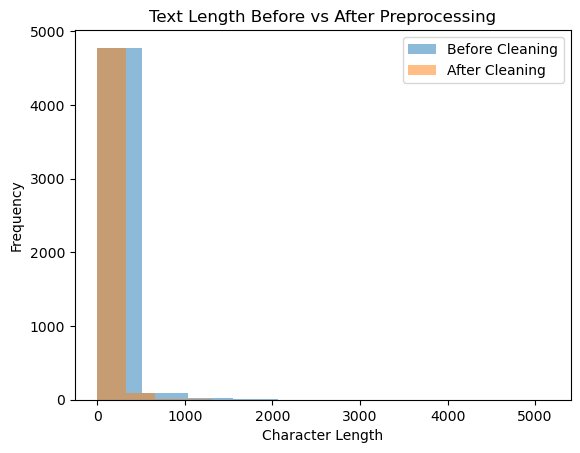

In [34]:
# Visual proof 
import matplotlib.pyplot as plt

plt.hist(df["before_length"], alpha=0.5, label="Before Cleaning")
plt.hist(df["after_length"], alpha=0.5, label="After Cleaning")

plt.legend()
plt.title("Text Length Before vs After Preprocessing")
plt.xlabel("Character Length")
plt.ylabel("Frequency")
plt.show()

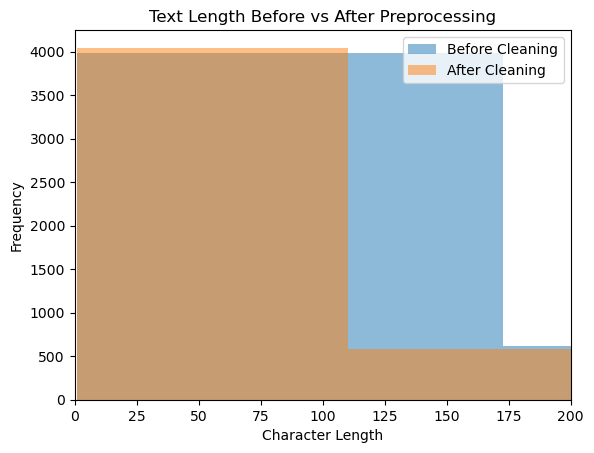

In [35]:
import matplotlib.pyplot as plt

plt.hist(df["before_length"], bins=30, alpha=0.5, label="Before Cleaning")
plt.hist(df["after_length"], bins=30, alpha=0.5, label="After Cleaning")

plt.xlim(0, 200)

plt.legend(loc="upper right")  # FIXED (no warning now)
plt.title("Text Length Before vs After Preprocessing")
plt.xlabel("Character Length")
plt.ylabel("Frequency")

plt.show()

In [36]:
# Random Inspection 
for i in range(5):
    print("BEFORE:", df["content"].iloc[i])
    print("AFTER :", df["clean_content"].iloc[i])
    print("-" * 60)

BEFORE: Im sorry but there are PLENTY of dicks in DayZ. Just no penis'.
AFTER : sorry plenty dick dayz penis
------------------------------------------------------------
BEFORE: At 7680 by 4320 with 64x AA, right?
AFTER : 7680 4320 64x aa right
------------------------------------------------------------
BEFORE: It really is the norm (atleast here in Europe).
AFTER : really norm atleast europe
------------------------------------------------------------
BEFORE: I think you're making that up, because that happened in real life in Mexico, on a particular highway people got kidnapped on a lot.
AFTER : think making happened real life mexico particular highway people got kidnapped lot
------------------------------------------------------------
BEFORE: Supernova?
AFTER : supernova
------------------------------------------------------------


In [37]:
# I am saving the cleaned dataset to a CSV file
df.to_csv("cleaned_reddit_data.csv", index=False)

In [38]:
from nltk.tokenize import word_tokenize

# Tokenizing each cleaned comment into individual words
df["tokens"] = df["content"].apply(lambda x: word_tokenize(str(x)))

In [39]:
print(df.columns)

Index(['content', 'user_id', 'parent_user_id', 'community', 'clean_content',
       'before_lemmatization', 'before_length', 'after_length', 'tokens'],
      dtype='object')


In [40]:
for i in range(5):
    print("Before:", df["content"].iloc[i])
    print("After :", df["tokens"].iloc[i])
    print("-" * 50)

Before: Im sorry but there are PLENTY of dicks in DayZ. Just no penis'.
After : ['Im', 'sorry', 'but', 'there', 'are', 'PLENTY', 'of', 'dicks', 'in', 'DayZ', '.', 'Just', 'no', 'penis', "'", '.']
--------------------------------------------------
Before: At 7680 by 4320 with 64x AA, right?
After : ['At', '7680', 'by', '4320', 'with', '64x', 'AA', ',', 'right', '?']
--------------------------------------------------
Before: It really is the norm (atleast here in Europe).
After : ['It', 'really', 'is', 'the', 'norm', '(', 'atleast', 'here', 'in', 'Europe', ')', '.']
--------------------------------------------------
Before: I think you're making that up, because that happened in real life in Mexico, on a particular highway people got kidnapped on a lot.
After : ['I', 'think', 'you', "'re", 'making', 'that', 'up', ',', 'because', 'that', 'happened', 'in', 'real', 'life', 'in', 'Mexico', ',', 'on', 'a', 'particular', 'highway', 'people', 'got', 'kidnapped', 'on', 'a', 'lot', '.']
---------

In [41]:
# checking if any coloume has been added 
print(df.columns)

Index(['content', 'user_id', 'parent_user_id', 'community', 'clean_content',
       'before_lemmatization', 'before_length', 'after_length', 'tokens'],
      dtype='object')


In [42]:
df["clean_content"].isnull().sum()

np.int64(0)

In [43]:
# normalize whitespace
df["clean_content"] = df["clean_content"].str.replace(r"\s+", " ", regex=True).str.strip()

In [44]:
df[["content", "clean_content"]].head(10)

,content,clean_content
0,Im sorry but there are PLENTY of dicks in DayZ...,sorry plenty dick dayz penis
1,"At 7680 by 4320 with 64x AA, right?",7680 4320 64x aa right
2,It really is the norm (atleast here in Europe).,really norm atleast europe
3,"I think you're making that up, because that ha...",think making happened real life mexico particu...
4,Supernova?,supernova
5,This is where grenades would come in handy...o...,grenade would come handyor suicide vest fuckin...
6,"Nice! I was going to go with ""I'm 40% DS!""",nice wa going go 40
7,"""[Different than] your run of the mill modern ...",different run mill modern military shooter fee...
8,"Nope, Bethesda has the selling rights now. We ...",nope bethesda ha selling right see deciede
9,"I remember trying the demo and thinking, 'meh.'",remember trying demo thinking meh


Text was heavily normalised to remove noise typical in social media data. This included stopword removal, punctuation removal, and lemmatization. As a result, the cleaned text is not intended to preserve grammatical structure or readability, but to represent semantic keywords for downstream NLP tasks such as topic modelling and network construction

# Sentiment Analysis

Sentiment analysis is applied to Reddit comments to measure public opinion on discussion topics. Using VADER from NLTK, each comment is assigned a compound score representing sentiment polarity. These scores are then classified as positive, negative, or neutral, enabling comparison of user attitudes across different Reddit discussions.

In [45]:
# I import the required libraries for data handling, visualization, and sentiment analysis
import pandas as pd
import matplotlib.pyplot as plt
import nltk

# I import VADER sentiment analyzer from NLTK
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# I download the VADER lexicon (required for sentiment scoring)
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/daniadonai/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [46]:
# I create an instance of the VADER sentiment analyzer
# This object will be used to compute sentiment scores for each comment
sia = SentimentIntensityAnalyzer()

In [47]:
# I am loading the cleaned Reddit dataset into a pandas DataFrame
df = pd.read_csv("cleaned_reddit_data.csv")

# I am previewing the first few rows to understand the structure of the Reddit data
df.head()

,content,user_id,parent_user_id,community,clean_content,before_lemmatization,before_length,after_length
0,Im sorry but there are PLENTY of dicks in DayZ...,eaa09e58-5428-5eaf-8f60-57af4025ca53,NaN,gaming,sorry plenty dick dayz penis,im sorry but there are plenty of dicks in dayz...,63,28
1,"At 7680 by 4320 with 64x AA, right?",96efa914-095b-5ca7-8ca4-f9242b4021d0,NaN,gaming,7680 4320 64x aa right,at 7680 by 4320 with 64x aa right,35,22
2,It really is the norm (atleast here in Europe).,0c9c375b-8eed-5f04-9cc2-988b92d596ee,NaN,gaming,really norm atleast europe,it really is the norm atleast here in europe,47,26
3,"I think you're making that up, because that ha...",a1b06573-3abd-534d-82d1-3fd4ad175916,NaN,gaming,think making happened real life mexico particu...,i think youre making that up because that happ...,131,82
4,Supernova?,1a1579ab-71b8-5c72-9b31-a838ba7c2093,NaN,gaming,supernova,supernova,10,9


In [48]:
df.columns

Index(['content', 'user_id', 'parent_user_id', 'community', 'clean_content',
       'before_lemmatization', 'before_length', 'after_length'],
      dtype='object')

In [49]:
# Function to compute VADER compound sentiment score for each text entry
def get_compound(text):
    return sia.polarity_scores(str(text))["compound"]

# Apply sentiment analysis to the cleaned content column
df["compound"] = df["clean_content"].apply(get_compound)

In [50]:
# Mapping VADER compound sentiment scores into discrete sentiment classes
def label_sentiment(score):
    if score > 0:
        return "positive"
    elif score < 0:
        return "negative"
    return "neutral"

df["sentiment"] = df["compound"].apply(label_sentiment)

In [51]:
# Display sample of cleaned Reddit content with sentiment results
df[["clean_content", "compound", "sentiment"]].head(10)

,clean_content,compound,sentiment
0,sorry plenty dick dayz penis,-0.5574,negative
1,7680 4320 64x aa right,0.0000,neutral
2,really norm atleast europe,0.0000,neutral
3,think making happened real life mexico particu...,0.0000,neutral
4,supernova,0.0000,neutral
5,grenade would come handyor suicide vest fuckin...,-0.8655,negative
6,nice wa going go 40,0.4215,positive
7,different run mill modern military shooter fee...,0.9136,positive
8,nope bethesda ha selling right see deciede,-0.2584,negative
9,remember trying demo thinking meh,-0.0772,negative


In [52]:
# Sentiment distribution as a DataFrame
sentiment_counts = df["sentiment"].value_counts().reset_index()
sentiment_counts.columns = ["sentiment", "count"]

sentiment_counts

,sentiment,count
0,positive,2352
1,neutral,1439
2,negative,1108


In [53]:
df["sentiment"].isna().sum()

np.int64(0)

In [54]:
df["content"].isna().sum()

np.int64(0)

In [55]:
print(df.columns)

Index(['content', 'user_id', 'parent_user_id', 'community', 'clean_content',
       'before_lemmatization', 'before_length', 'after_length', 'compound',
       'sentiment'],
      dtype='object')


# SENTIMENT ANALYSIS OF REDDIT SOCIAL MEDIA DATA

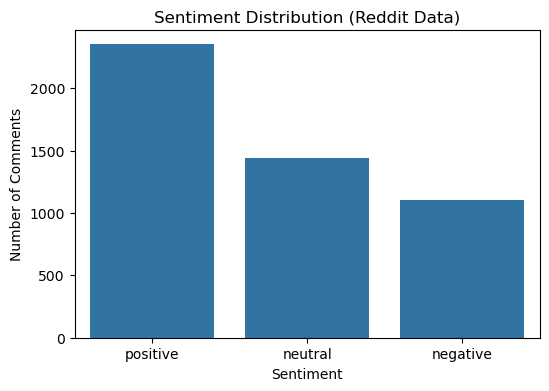

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

sent_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=sent_counts.index, y=sent_counts.values)

plt.title("Sentiment Distribution (Reddit Data)")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")

plt.show()

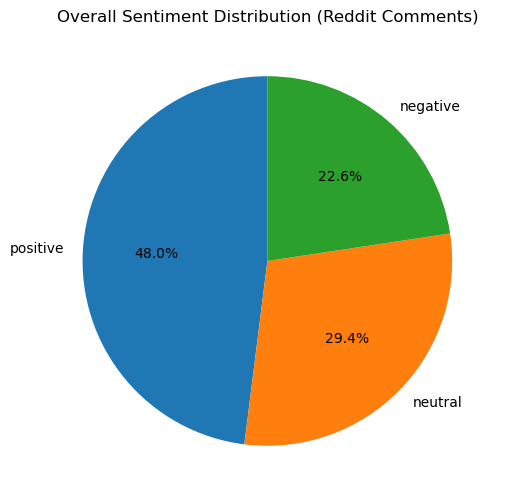

In [57]:
import matplotlib.pyplot as plt

sent_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    sent_counts,
    labels=sent_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Sentiment Distribution (Reddit Comments)")
plt.show()

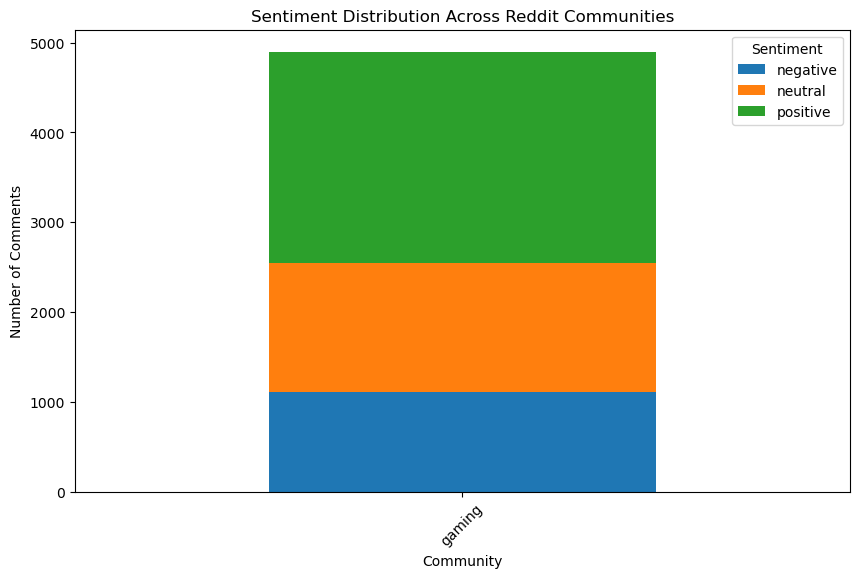

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

community_sent = df.groupby(["community", "sentiment"]).size().unstack().fillna(0)

community_sent.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Sentiment Distribution Across Reddit Communities")
plt.xlabel("Community")
plt.ylabel("Number of Comments")

plt.xticks(rotation=45)
plt.legend(title="Sentiment")

plt.show()

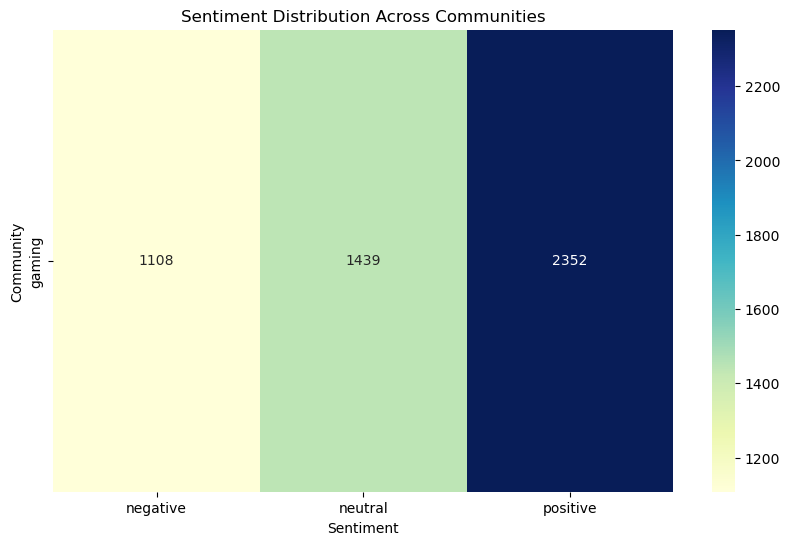

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = df.pivot_table(
    index="community",
    columns="sentiment",
    values="content",
    aggfunc="count",
    fill_value=0
)

plt.figure(figsize=(10,6))

sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu")

plt.title("Sentiment Distribution Across Communities")
plt.xlabel("Sentiment")
plt.ylabel("Community")

plt.show()

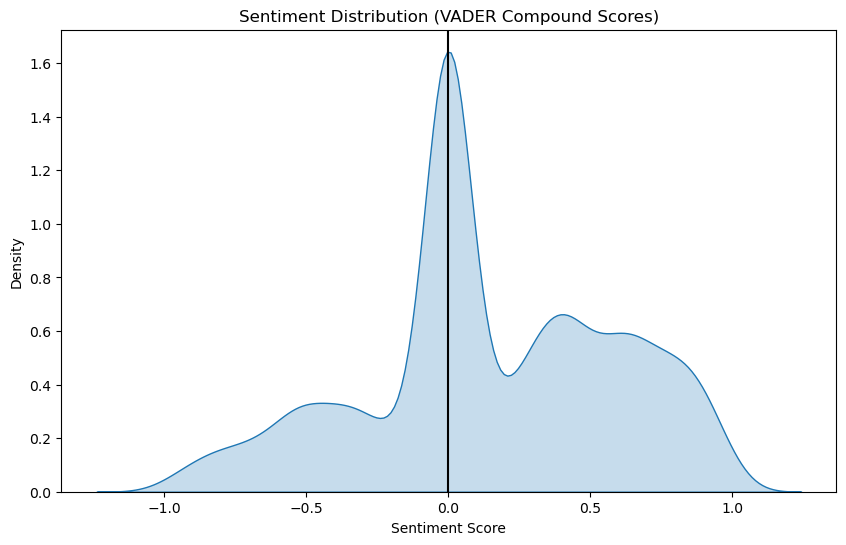

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.kdeplot(df["compound"], fill=True)

plt.title("Sentiment Distribution (VADER Compound Scores)")
plt.xlabel("Sentiment Score")
plt.ylabel("Density")

plt.axvline(0, color="black")

plt.show()

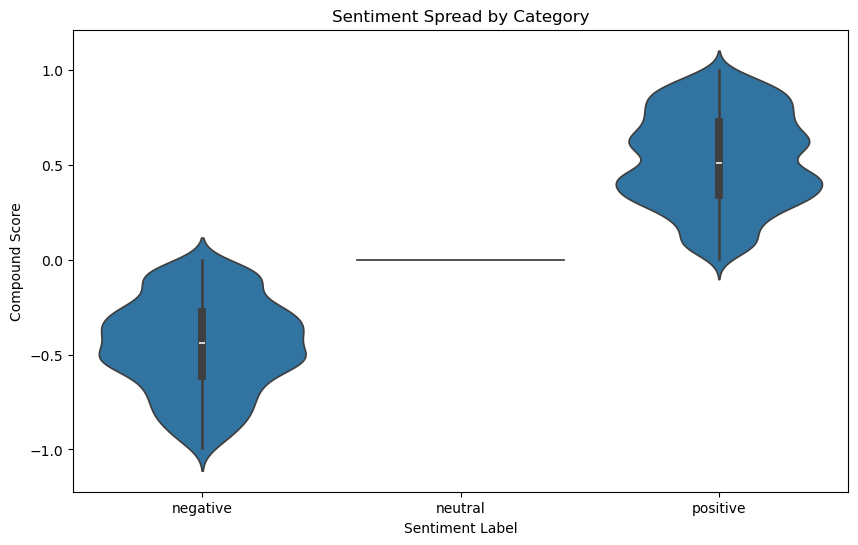

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.violinplot(x="sentiment", y="compound", data=df)

plt.title("Sentiment Spread by Category")
plt.xlabel("Sentiment Label")
plt.ylabel("Compound Score")

plt.show()

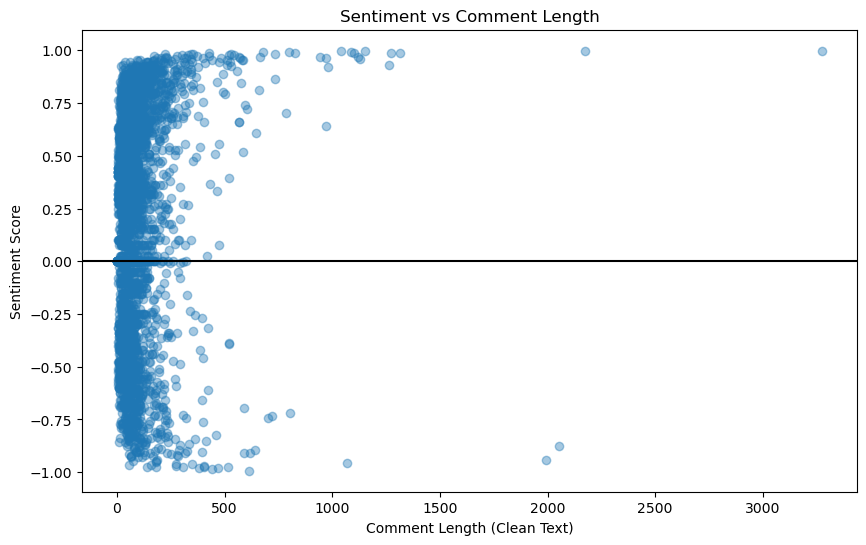

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(df["after_length"], df["compound"], alpha=0.4)

plt.title("Sentiment vs Comment Length")
plt.xlabel("Comment Length (Clean Text)")
plt.ylabel("Sentiment Score")

plt.axhline(0, color="black")

plt.show()

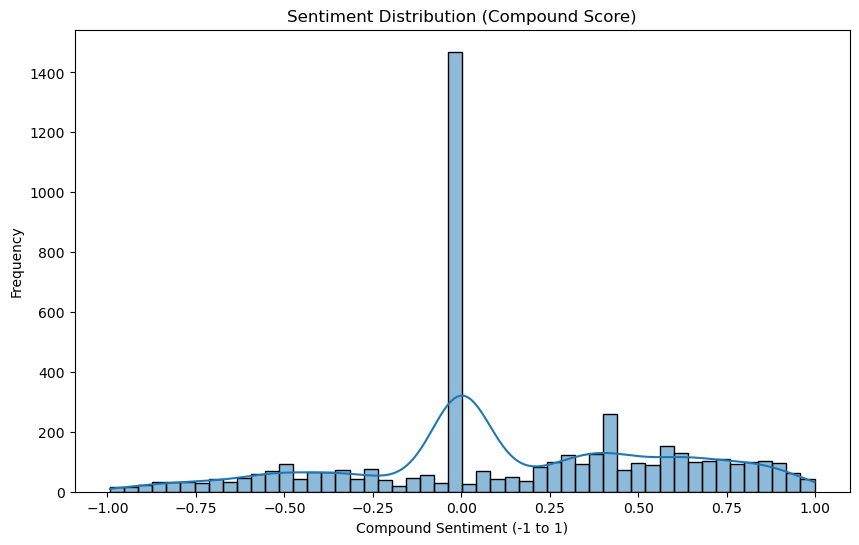

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(df["compound"], bins=50, kde=True)

plt.title("Sentiment Distribution (Compound Score)")
plt.xlabel("Compound Sentiment (-1 to 1)")
plt.ylabel("Frequency")

plt.show()

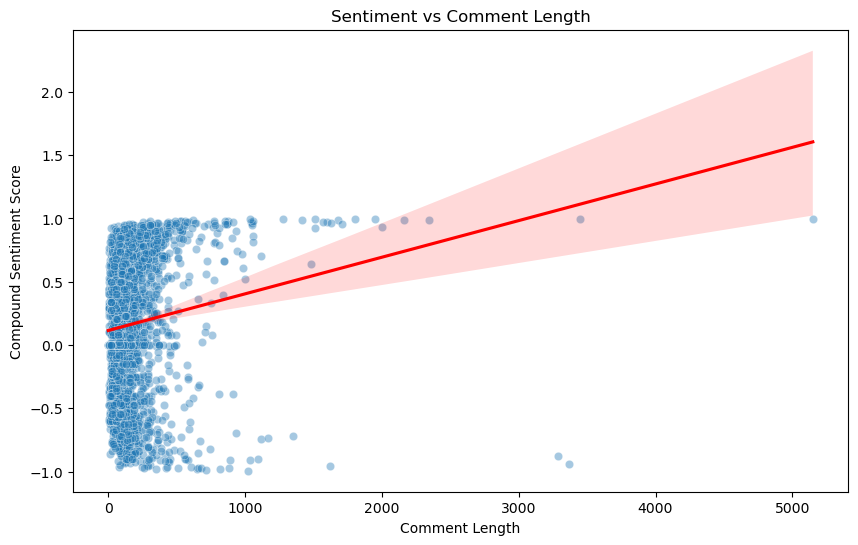

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

df["comment_length"] = df["content"].astype(str).apply(len)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="comment_length",
    y="compound",
    alpha=0.4
)

sns.regplot(
    data=df,
    x="comment_length",
    y="compound",
    scatter=False,
    color="red"
)

plt.title("Sentiment vs Comment Length")
plt.xlabel("Comment Length")
plt.ylabel("Compound Sentiment Score")

plt.show()

# Sentiment Analysis Pipeline

* Sentiment analysis is done after text preprocessing is completed
* Input dataset: reddit_cleaned.csv (cleaned Reddit comments)
* Sentiment is calculated using VADER on the content column
* A compound score is generated for each comment
* Scores are converted into labels:
    * Positive
    * Neutral
    * Negative
* Final dataset is saved as reddit_sentiment.csv
* This step is separate from preprocessing and topic modeling
* Raw and cleaned data must not be overwritten during this stage

In [65]:
# Saving the final sentiment analysis output dataset
# This file contains the original Reddit content, sentiment score (compound),
# and sentiment label (positive / neutral / negative).
# This is a separate stage output and does NOT overwrite the cleaned dataset.

df.to_csv("reddit_sentiment_data.csv", index=False)

In [66]:
df.shape

(4899, 11)

In [67]:
len(df.columns)

11

In [68]:
list(df.columns)

['content',
 'user_id',
 'parent_user_id',
 'community',
 'clean_content',
 'before_lemmatization',
 'before_length',
 'after_length',
 'compound',
 'sentiment',
 'comment_length']

# Topic Modelling Analysis (Reddit Dataset)

In [69]:
import pandas as pd

# I am loading the cleaned dataset as the input for topic modelling
df = pd.read_csv("cleaned_reddit_data.csv")

# I am previewing the dataset to understand its structure
df.head()

,content,user_id,parent_user_id,community,clean_content,before_lemmatization,before_length,after_length
0,Im sorry but there are PLENTY of dicks in DayZ...,eaa09e58-5428-5eaf-8f60-57af4025ca53,NaN,gaming,sorry plenty dick dayz penis,im sorry but there are plenty of dicks in dayz...,63,28
1,"At 7680 by 4320 with 64x AA, right?",96efa914-095b-5ca7-8ca4-f9242b4021d0,NaN,gaming,7680 4320 64x aa right,at 7680 by 4320 with 64x aa right,35,22
2,It really is the norm (atleast here in Europe).,0c9c375b-8eed-5f04-9cc2-988b92d596ee,NaN,gaming,really norm atleast europe,it really is the norm atleast here in europe,47,26
3,"I think you're making that up, because that ha...",a1b06573-3abd-534d-82d1-3fd4ad175916,NaN,gaming,think making happened real life mexico particu...,i think youre making that up because that happ...,131,82
4,Supernova?,1a1579ab-71b8-5c72-9b31-a838ba7c2093,NaN,gaming,supernova,supernova,10,9


In [70]:
# I am only removing missing values to ensure data quality
df = df[df["clean_content"].notna()]

In [71]:
print(df.columns)

Index(['content', 'user_id', 'parent_user_id', 'community', 'clean_content',
       'before_lemmatization', 'before_length', 'after_length'],
      dtype='object')


In [72]:
# I am ensuring only valid text is used
df = df[df["clean_content"].notna()]

In [73]:
from nltk.tokenize import word_tokenize

# I am creating tokens from clean text for topic modelling
df["tokens"] = df["clean_content"].apply(lambda x: word_tokenize(str(x)))

In [74]:
tokens = df["tokens"]

In [75]:
from nltk.tokenize import word_tokenize

# I am creating tokens from clean_content
df["tokens"] = df["clean_content"].apply(lambda x: word_tokenize(str(x)))

In [76]:
from gensim.corpora import Dictionary

# I am building a dictionary from tokens
dictionary = Dictionary(df["tokens"])
dictionary.filter_extremes(no_below=5, no_above=0.5)

In [77]:
# I am converting tokens into bag-of-words format
corpus = [dictionary.doc2bow(text) for text in df["tokens"]]

In [78]:
from gensim.models import LdaModel

# I am training LDA model for topic discovery
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    passes=10,
    random_state=42
)

In [79]:
# I am assigning the dominant topic for each document

def get_dominant_topic(bow):
    topics = lda_model.get_document_topics(bow)
    return max(topics, key=lambda x: x[1])[0] if topics else None

df["topic"] = [get_dominant_topic(bow) for bow in corpus]

In [80]:
import pandas as pd

# I am loading the cleaned dataset for topic modelling stage
df = pd.read_csv("cleaned_reddit_data.csv")

In [81]:
# I am assigning the dominant topic for each document
df["topic"] = [get_dominant_topic(bow) for bow in corpus]

In [82]:
# I am saving a separate dataset for topic modelling results
df.to_csv("reddit_topic_data.csv", index=False)

In [83]:
# I am displaying top words for each topic to understand meaning

for i in range(lda_model.num_topics):
    print(f"\nTopic {i}")
    print(lda_model.show_topic(i, 10))


Topic 0
[('game', np.float32(0.046803266)), ('one', np.float32(0.01771378)), ('wii', np.float32(0.017036812)), ('u', np.float32(0.016908657)), ('play', np.float32(0.013355081)), ('wa', np.float32(0.011268375)), ('xbox', np.float32(0.010738718)), ('console', np.float32(0.009298489)), ('like', np.float32(0.008917513)), ('ps4', np.float32(0.008728898))]

Topic 1
[('wa', np.float32(0.033648018)), ('game', np.float32(0.029064855)), ('like', np.float32(0.019798853)), ('good', np.float32(0.013069576)), ('got', np.float32(0.012005771)), ('think', np.float32(0.010642177)), ('one', np.float32(0.010524591)), ('love', np.float32(0.009621405)), ('would', np.float32(0.008825115)), ('fucking', np.float32(0.00841805))]

Topic 2
[('game', np.float32(0.019372286)), ('nintendo', np.float32(0.016876133)), ('ha', np.float32(0.01595834)), ('3d', np.float32(0.012035824)), ('get', np.float32(0.010966611)), ('console', np.float32(0.010432546)), ('mario', np.float32(0.008676614)), ('would', np.float32(0.008612

# all above is a graph

In [84]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

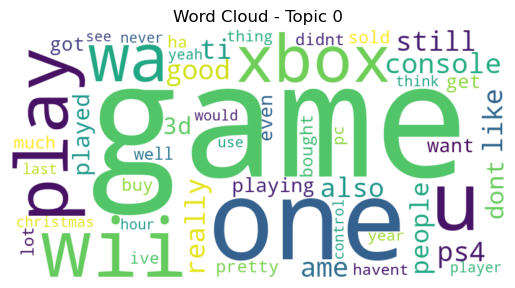

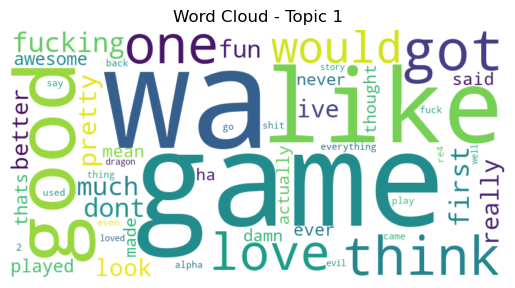

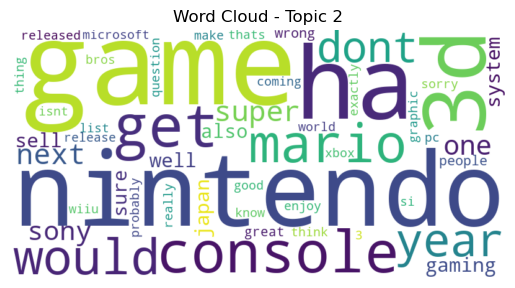

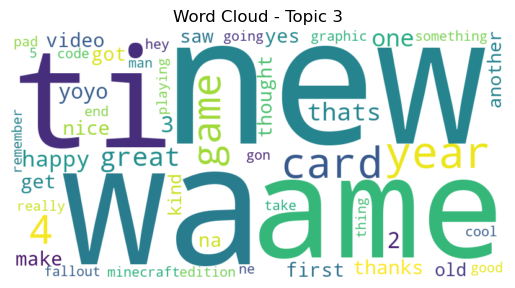

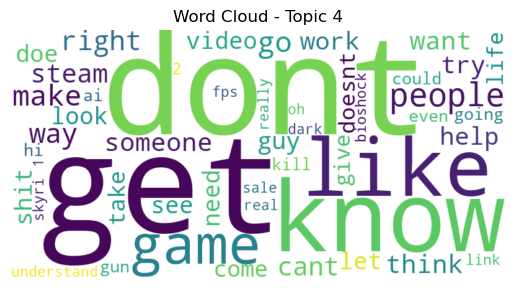

In [85]:
# I am generating word clouds for all topics

for topic_id in range(lda_model.num_topics):
    words = lda_model.show_topic(topic_id, 50)
    word_freq = {word: weight for word, weight in words}

    wc = WordCloud(width=800, height=400, background_color="white")
    wc.generate_from_frequencies(word_freq)

    plt.figure()
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud - Topic {topic_id}")
    plt.show()

In [86]:
!pip install pyLDAvis

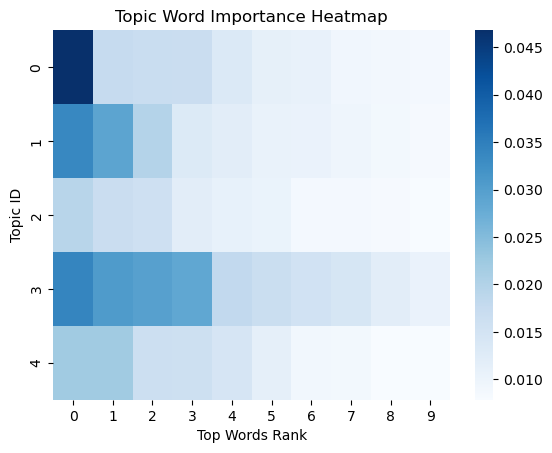

In [87]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# I am extracting top words for all topics
all_topics = []

for i in range(lda_model.num_topics):
    all_topics.append([w[1] for w in lda_model.show_topic(i, 10)])

# I am creating a heatmap
plt.figure()
sns.heatmap(np.array(all_topics), cmap="Blues")
plt.title("Topic Word Importance Heatmap")
plt.xlabel("Top Words Rank")
plt.ylabel("Topic ID")
plt.show()

In [88]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# I am preparing interactive topic visualisation
vis = gensimvis.prepare(lda_model, corpus, dictionary)

pyLDAvis.display(vis)

In [89]:
# I am checking all available columns in the dataset
print(df.columns)

Index(['content', 'user_id', 'parent_user_id', 'community', 'clean_content',
       'before_lemmatization', 'before_length', 'after_length', 'topic'],
      dtype='object')


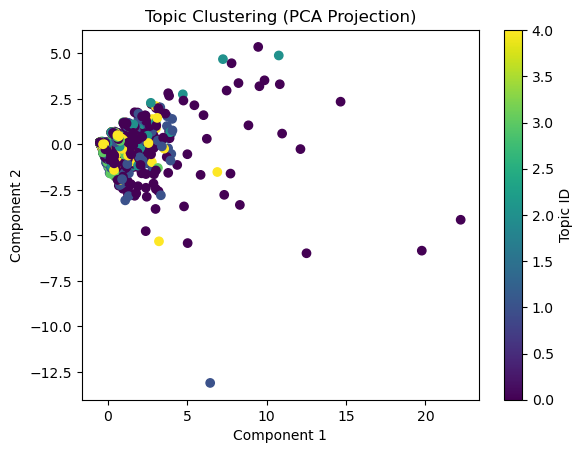

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# I am converting corpus into numeric form
X = np.array([[dict(doc).get(i, 0) for i in range(len(dictionary))] for doc in corpus])

# I am reducing topic space to 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

# I am visualising topic clustering
plt.figure()
plt.scatter(coords[:, 0], coords[:, 1], c=df["topic"], cmap="viridis")
plt.title("Topic Clustering (PCA Projection)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Topic ID")
plt.show()

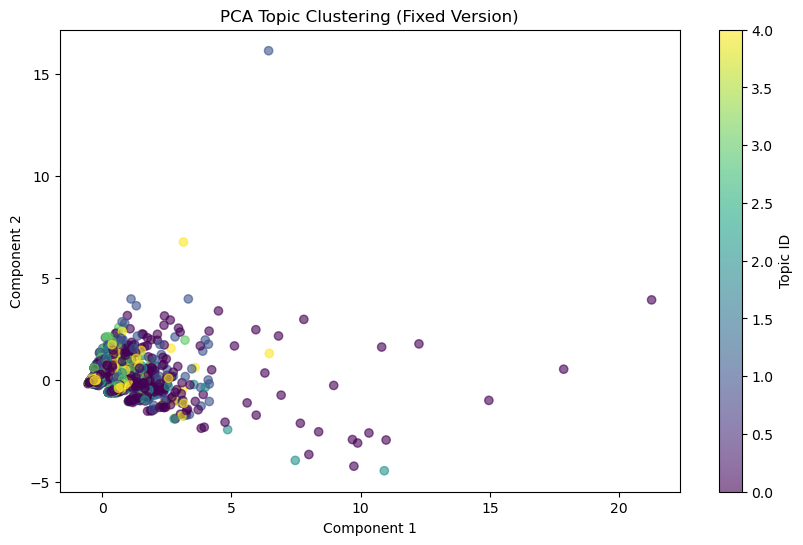

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer

# I am using clean text instead of tokens
texts = df["clean_content"].astype(str)

# I am converting text into numerical features
vectorizer = CountVectorizer(max_features=1000)
X = vectorizer.fit_transform(texts).toarray()

# I am reducing dimensions using PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

# I am plotting topic clusters
plt.figure(figsize=(10, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=df["topic"], cmap="viridis", alpha=0.6)

plt.title("PCA Topic Clustering (Fixed Version)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Topic ID")
plt.show()